Importing required libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import statsmodels.api as sm

In [3]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder , OneHotEncoder
from sklearn.utils import estimator_html_repr
from sklearn import set_config
set_config(display='diagram')

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

In [5]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV

In [6]:
import joblib

In [7]:
## Importing the test data

dataset = pd.read_csv('../input/titanic/train.csv')

In [8]:
## Making a copy of a imported dataset

df = dataset.copy()

In [9]:
## dataframe info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
## first 5 rows of the dataframe

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
## Removing the passengerID column

df = df.iloc[:,1:]

In [13]:
## Checking first 5 rows again

df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
## we can understand by simple common sense that the survival can't be related to the name or the ticket number of the 
# passenger and hence we can remove the name and Ticket feature

df = df.drop(columns=['Name','Ticket'])

In [15]:
## checking the first 5 rows of the dataframe

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [16]:
## Checking for missing values in each feature

df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [17]:
## Finding the numerical and categorical features in the dataset

cat_feat = [feature for feature in df.columns if df[feature].dtypes == 'O']

num_feat = [feature for feature in df.columns if feature not in cat_feat]

In [18]:
print(f"Categorical features are: {cat_feat}\n")
print(f"Numerical features are: {num_feat}")

Categorical features are: ['Sex', 'Cabin', 'Embarked']

Numerical features are: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


Even though we have got Pclass, SibSp and Parch in num_feat, they are categorical column. So changing cat_feat and num_feat accordingly

In [19]:
cat_feat.append('Pclass')
cat_feat.append('SibSp')
cat_feat.append('Parch')
num_feat.remove('Pclass')
num_feat.remove('SibSp')
num_feat.remove('Parch')

In [20]:
print(f"Categorical features are: {cat_feat}\n")
print(f"Numerical features are: {num_feat}")

Categorical features are: ['Sex', 'Cabin', 'Embarked', 'Pclass', 'SibSp', 'Parch']

Numerical features are: ['Survived', 'Age', 'Fare']


Removing Survived feature (dependent feature) as we won't be using it in preprocessing

In [21]:
num_feat = num_feat[1:]
print(f"Numerical features are: {num_feat}")


Numerical features are: ['Age', 'Fare']


In [22]:
## Finding the number of unique values in each of the categorical features

df[cat_feat].nunique()

Sex           2
Cabin       147
Embarked      3
Pclass        3
SibSp         7
Parch         7
dtype: int64

In [23]:
## Checking if the data given is imbalanced or not

df['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

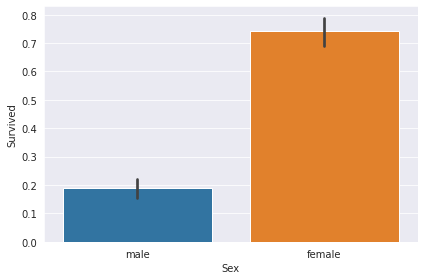

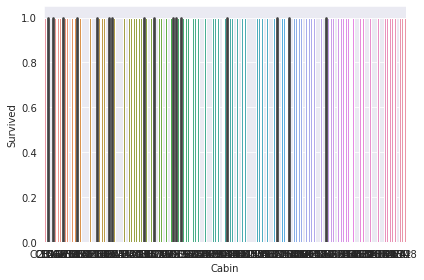

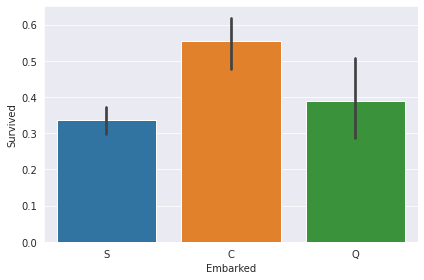

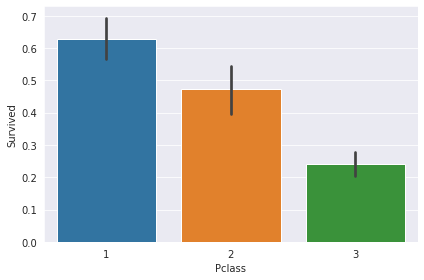

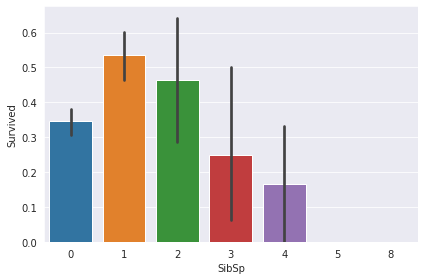

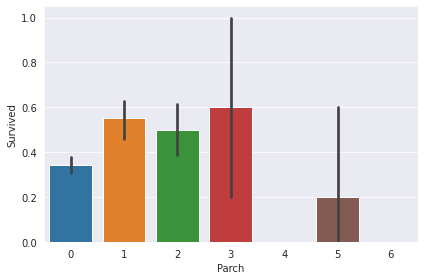

In [24]:
## Checking the dependency of the independent categorical features and dependent feature

sns.set_style('darkgrid')
for feature in cat_feat:
    sns.barplot(x=feature,y='Survived',data=df)
    plt.tight_layout()
    plt.show()

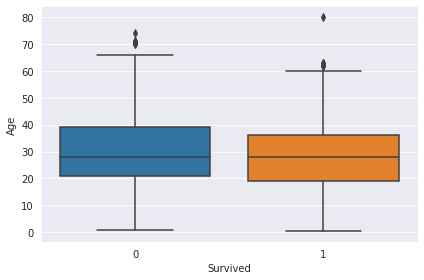

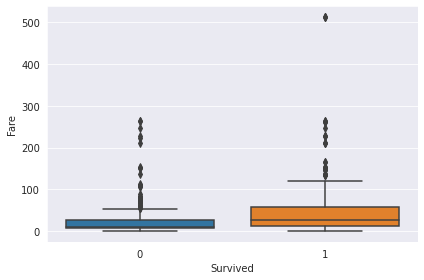

In [25]:
for feature in num_feat:
    sns.boxplot(x='Survived',y=feature,data=df)
    plt.tight_layout()
    plt.show()

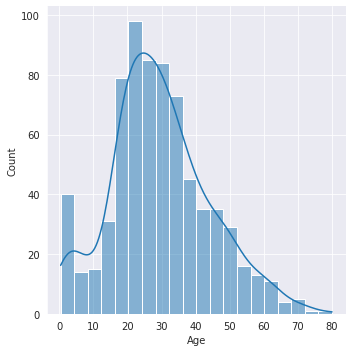

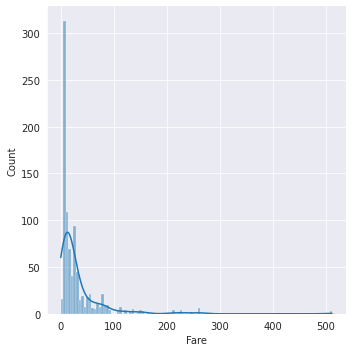

In [26]:
## Checking the distribution of every numerical column

for feature in num_feat:
    sns.displot(df[feature],kde=True)
    plt.tight_layout()
    plt.show()

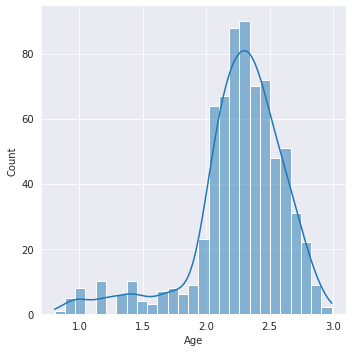

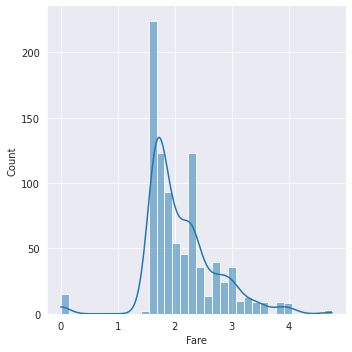

In [27]:
## Checking the distribution of Fare column after powering it to 0.25
for feature in num_feat:
    sns.displot(df[feature]**(1/4),kde=True)
    plt.tight_layout()
    plt.show()

Splitting the dataset into independent features and dependent features

In [28]:
y = df.iloc[:,0:1].copy()
X  = df.iloc[:,1:].copy()

In [29]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,22.0,1,0,7.2500,NaN,S
1,1,female,38.0,1,0,71.2833,C85,C
2,3,female,26.0,0,0,7.9250,NaN,S
3,1,female,35.0,1,0,53.1000,C123,S
4,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,NaN,S
887,1,female,19.0,0,0,30.0000,B42,S
888,3,female,NaN,1,2,23.4500,NaN,S
889,1,male,26.0,0,0,30.0000,C148,C


In [30]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


Creating a column transformer to remove the outliers from the dataset

In [31]:
class OutlierRemover(BaseEstimator,TransformerMixin):
    def __init__(self,factor=1.5):
        self.factor = factor

    def fit(self,X,y=None):
        return self

    def transform(self,X,y=None):
        z = pd.DataFrame(X).copy()
        for i in range(z.shape[1]):
            Q1 = z.iloc[:,i].quantile(0.25)
            Q3 = z.iloc[:,i].quantile(0.75)
            IQR = Q3 - Q1
            z = z[(z.iloc[:,i] > (Q1 - self.factor*IQR)) | (z.iloc[:,i] < (Q3 + self.factor*IQR))]
        return z

In [32]:
class UselessFeatureRemoval(BaseEstimator,TransformerMixin):
    def __init__(self,factor=1.5):
        self.factor = factor

    def fit(self,X,y=None):
        return self

    def transform(self,X,y=None):
        z = pd.DataFrame(X).copy()
        

In [33]:
## for Fare and Age features
num_pipeline = Pipeline([

        ('num_imputer',SimpleImputer(strategy='median')),
        ('outlier_remover',OutlierRemover()),
        ('num_std_scalar',StandardScaler())

])

## for Cabin feature
cat_pipeline1 = Pipeline([

        ('cat_imputer1',SimpleImputer(strategy='constant',fill_value = "Missing")),
        ('ordinal_encoding',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=150))
])

## for Sex and Embarked features
cat_pipeline2 = Pipeline([

        ('cat_imputer2',SimpleImputer(strategy='most_frequent')),
        ('ohe_hot_encoding',OneHotEncoder(handle_unknown='ignore',sparse=False))
])


In [34]:
preprocess_pipeline = ColumnTransformer([

        ('num_pipeline',num_pipeline,num_feat),
        ('cat_pipeline1',cat_pipeline1,['Cabin']),
        ('cat_pipeline2',cat_pipeline2,['Sex','Embarked'])
], remainder="passthrough")

In [35]:
import pickle

with open('/kaggle/working/preprocess_pipeline.pkl', 'wb') as f:
    pickle.dump(preprocess_pipeline,f)

In [36]:
model_pipeline1 = Pipeline([

    ('model1_pipeline',LogisticRegression(max_iter=1000,random_state=1999))
])

model_pipeline2 = Pipeline([

    ('model2_pipeline',RandomForestClassifier(random_state=1988))
])

model_pipeline3 = Pipeline([

    ('model3_pipeline',KNeighborsClassifier())
])

In [37]:
full_pipeline1 = Pipeline([

    ('preprocessing',preprocess_pipeline),
    ('feature_selection',SelectKBest(f_classif,k=6)),
    ('model_training1',model_pipeline1)
    
])

full_pipeline2 = Pipeline([

    ('preprocessing',preprocess_pipeline),
    ('feature_selection',SelectKBest(f_classif,k=6)),
    ('model_training2',model_pipeline2)
    
])

full_pipeline3 = Pipeline([

    ('preprocessing',preprocess_pipeline),
    ('feature_selection',SelectKBest(f_classif,k=6)),
    ('model_training3',model_pipeline3)
    
])

In [38]:
full_pipeline1

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_pipeline',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('outlier_remover',
                                                                   OutlierRemover()),
                                                                  ('num_std_scalar',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat_pipeline1',
                                                  Pipeline(steps=[('cat_imputer1',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strat...
                                                                                  unknown_value=150))]),
                                                  ['Cabin']),
                                                 ('cat_pipeline2',
                                                  Pipeline(steps=[('cat_imputer2',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe_hot_encoding',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  ['Sex', 'Embarked'])])),
                ('feature_selection', SelectKBest(k=6)),
                ('model_training1',
                 Pipeline(steps=[('model1_pipeline',
                                  LogisticRegression(max_iter=1000,
                                                     random_state=1999))]))])

saving the full pipeline 1 as a html file

In [39]:
with open('/kaggle/working/full_pipeline1.html','w',encoding="utf-8") as f:
    f.write(estimator_html_repr(full_pipeline1))

In [40]:
full_pipeline2  

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_pipeline',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('outlier_remover',
                                                                   OutlierRemover()),
                                                                  ('num_std_scalar',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat_pipeline1',
                                                  Pipeline(steps=[('cat_imputer1',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strat...
                                                                                  unknown_value=150))]),
                                                  ['Cabin']),
                                                 ('cat_pipeline2',
                                                  Pipeline(steps=[('cat_imputer2',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe_hot_encoding',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  ['Sex', 'Embarked'])])),
                ('feature_selection', SelectKBest(k=6)),
                ('model_training2',
                 Pipeline(steps=[('model2_pipeline',
                                  RandomForestClassifier(random_state=1988))]))])

Saving full pipeline 2 as html file

In [41]:
with open('/kaggle/working/full_pipeline2.html','w',encoding="utf-8") as f:
    f.write(estimator_html_repr(full_pipeline2))

In [42]:
full_pipeline3

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_pipeline',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('outlier_remover',
                                                                   OutlierRemover()),
                                                                  ('num_std_scalar',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat_pipeline1',
                                                  Pipeline(steps=[('cat_imputer1',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strat...
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=150))]),
                                                  ['Cabin']),
                                                 ('cat_pipeline2',
                                                  Pipeline(steps=[('cat_imputer2',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe_hot_encoding',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  ['Sex', 'Embarked'])])),
                ('feature_selection', SelectKBest(k=6)),
                ('model_training3',
                 Pipeline(steps=[('model3_pipeline',
                                  KNeighborsClassifier())]))])

Saving full pipeline 3 as html file

In [43]:
with open('/kaggle/working/full_pipeline3.html','w',encoding="utf-8") as f:
    f.write(estimator_html_repr(full_pipeline3))

In [44]:
### Performing cross-validation to choose the model

skf = StratifiedKFold(shuffle=True,random_state=3638)
score1 = cross_val_score(full_pipeline1,X,y.to_numpy().ravel(),scoring='accuracy',cv=skf,error_score='raise')
score2 = cross_val_score(full_pipeline2,X,y.to_numpy().ravel(),scoring='accuracy',cv=skf,error_score='raise')
score3 = cross_val_score(full_pipeline3,X,y.to_numpy().ravel(),scoring='accuracy',cv=skf,error_score='raise')

print(f"The cross validation score for the logistic regression is {np.round(score1.mean(),3)} +/- {np.round(score1.std(),3)}")
print(f"The cross validation score for the random forest classifer is {np.round(score2.mean(),3)} +/- {np.round(score2.std(),3)}")
print(f"The cross validation score for the k neighbors classifiers is {np.round(score3.mean(),3)} +/- {np.round(score3.std(),3)}")

The cross validation score for the logistic regression is 0.785 +/- 0.027
The cross validation score for the random forest classifer is 0.811 +/- 0.028
The cross validation score for the k neighbors classifiers is 0.806 +/- 0.02


In [45]:
full_pipeline1.get_params().keys()

dict_keys(['memory', 'steps', 'verbose', 'preprocessing', 'feature_selection', 'model_training1', 'preprocessing__n_jobs', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 'preprocessing__transformers', 'preprocessing__verbose', 'preprocessing__verbose_feature_names_out', 'preprocessing__num_pipeline', 'preprocessing__cat_pipeline1', 'preprocessing__cat_pipeline2', 'preprocessing__num_pipeline__memory', 'preprocessing__num_pipeline__steps', 'preprocessing__num_pipeline__verbose', 'preprocessing__num_pipeline__num_imputer', 'preprocessing__num_pipeline__outlier_remover', 'preprocessing__num_pipeline__num_std_scalar', 'preprocessing__num_pipeline__num_imputer__add_indicator', 'preprocessing__num_pipeline__num_imputer__copy', 'preprocessing__num_pipeline__num_imputer__fill_value', 'preprocessing__num_pipeline__num_imputer__missing_values', 'preprocessing__num_pipeline__num_imputer__strategy', 'preprocessing__num_pipeline__num_imputer__ve

In [46]:
params1 = {}

params1['model_training1__model1_pipeline__C'] = np.arange(1,10,1)

In [47]:
result1 = GridSearchCV(full_pipeline1,params1,scoring='accuracy')
result1.fit(X,y.to_numpy().ravel())
result1

GridSearchCV(estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num_pipeline',
                                                                         Pipeline(steps=[('num_imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('outlier_remover',
                                                                                          OutlierRemover()),
                                                                                         ('num_std_scalar',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Fare']),
                                                                        ('cat_pipeline1',
                                                                         Pipeline(steps=[('cat_imputer1',
                                                                                          SimpleImputer(fil...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe_hot_encoding',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse=False))]),
                                                                         ['Sex',
                                                                          'Embarked'])])),
                                       ('feature_selection', SelectKBest(k=6)),
                                       ('model_training1',
                                        Pipeline(steps=[('model1_pipeline',
                                                         LogisticRegression(max_iter=1000,
                                                                            random_state=1999))]))]),
             param_grid={'model_training1__model1_pipeline__C': array([1, 2, 3, 4, 5, 6, 7, 8, 9])},
             scoring='accuracy')

In [48]:
result1.best_params_

{'model_training1__model1_pipeline__C': 3}

In [49]:
full_pipeline1['model_training1'].named_steps['model1_pipeline'].set_params(C=3)

LogisticRegression(C=3, max_iter=1000, random_state=1999)

In [50]:
full_pipeline2.get_params().keys()

dict_keys(['memory', 'steps', 'verbose', 'preprocessing', 'feature_selection', 'model_training2', 'preprocessing__n_jobs', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 'preprocessing__transformers', 'preprocessing__verbose', 'preprocessing__verbose_feature_names_out', 'preprocessing__num_pipeline', 'preprocessing__cat_pipeline1', 'preprocessing__cat_pipeline2', 'preprocessing__num_pipeline__memory', 'preprocessing__num_pipeline__steps', 'preprocessing__num_pipeline__verbose', 'preprocessing__num_pipeline__num_imputer', 'preprocessing__num_pipeline__outlier_remover', 'preprocessing__num_pipeline__num_std_scalar', 'preprocessing__num_pipeline__num_imputer__add_indicator', 'preprocessing__num_pipeline__num_imputer__copy', 'preprocessing__num_pipeline__num_imputer__fill_value', 'preprocessing__num_pipeline__num_imputer__missing_values', 'preprocessing__num_pipeline__num_imputer__strategy', 'preprocessing__num_pipeline__num_imputer__ve

In [51]:
params2 = {}

params2['model_training2__model2_pipeline__n_estimators'] = np.arange(100,1000,100)
params2['model_training2__model2_pipeline__criterion'] = ['gini','entropy']

params2

{'model_training2__model2_pipeline__n_estimators': array([100, 200, 300, 400, 500, 600, 700, 800, 900]),
 'model_training2__model2_pipeline__criterion': ['gini', 'entropy']}

In [52]:
result2 = GridSearchCV(full_pipeline2,params2,scoring='accuracy')
result2.fit(X,y.to_numpy().ravel())

GridSearchCV(estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num_pipeline',
                                                                         Pipeline(steps=[('num_imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('outlier_remover',
                                                                                          OutlierRemover()),
                                                                                         ('num_std_scalar',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Fare']),
                                                                        ('cat_pipeline1',
                                                                         Pipeline(steps=[('cat_imputer1',
                                                                                          SimpleImputer(fil...
                                                                         ['Sex',
                                                                          'Embarked'])])),
                                       ('feature_selection', SelectKBest(k=6)),
                                       ('model_training2',
                                        Pipeline(steps=[('model2_pipeline',
                                                         RandomForestClassifier(random_state=1988))]))]),
             param_grid={'model_training2__model2_pipeline__criterion': ['gini',
                                                                         'entropy'],
                         'model_training2__model2_pipeline__n_estimators': array([100, 200, 300, 400, 500, 600, 700, 800, 900])},
             scoring='accuracy')

In [53]:
result2.best_params_

{'model_training2__model2_pipeline__criterion': 'gini',
 'model_training2__model2_pipeline__n_estimators': 200}

In [54]:
full_pipeline2['model_training2'].named_steps['model2_pipeline'].set_params(n_estimators=200,criterion='gini')

RandomForestClassifier(n_estimators=200, random_state=1988)

In [55]:
full_pipeline3.get_params().keys()

dict_keys(['memory', 'steps', 'verbose', 'preprocessing', 'feature_selection', 'model_training3', 'preprocessing__n_jobs', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 'preprocessing__transformers', 'preprocessing__verbose', 'preprocessing__verbose_feature_names_out', 'preprocessing__num_pipeline', 'preprocessing__cat_pipeline1', 'preprocessing__cat_pipeline2', 'preprocessing__num_pipeline__memory', 'preprocessing__num_pipeline__steps', 'preprocessing__num_pipeline__verbose', 'preprocessing__num_pipeline__num_imputer', 'preprocessing__num_pipeline__outlier_remover', 'preprocessing__num_pipeline__num_std_scalar', 'preprocessing__num_pipeline__num_imputer__add_indicator', 'preprocessing__num_pipeline__num_imputer__copy', 'preprocessing__num_pipeline__num_imputer__fill_value', 'preprocessing__num_pipeline__num_imputer__missing_values', 'preprocessing__num_pipeline__num_imputer__strategy', 'preprocessing__num_pipeline__num_imputer__ve

In [56]:
params3 = {}

params3['model_training3__model3_pipeline__n_neighbors'] = np.arange(5,15,1)
params3['model_training3__model3_pipeline__weights'] = ['uniform','distance']
params3['model_training3__model3_pipeline__algorithm'] = ['auto','ball_tree','kd_tree','brute']

params3

{'model_training3__model3_pipeline__n_neighbors': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 'model_training3__model3_pipeline__weights': ['uniform', 'distance'],
 'model_training3__model3_pipeline__algorithm': ['auto',
  'ball_tree',
  'kd_tree',
  'brute']}

In [57]:
result3 = GridSearchCV(full_pipeline3,params3,scoring='accuracy')
result3.fit(X,y.to_numpy().ravel())

GridSearchCV(estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num_pipeline',
                                                                         Pipeline(steps=[('num_imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('outlier_remover',
                                                                                          OutlierRemover()),
                                                                                         ('num_std_scalar',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Fare']),
                                                                        ('cat_pipeline1',
                                                                         Pipeline(steps=[('cat_imputer1',
                                                                                          SimpleImputer(fil...
                                       ('feature_selection', SelectKBest(k=6)),
                                       ('model_training3',
                                        Pipeline(steps=[('model3_pipeline',
                                                         KNeighborsClassifier())]))]),
             param_grid={'model_training3__model3_pipeline__algorithm': ['auto',
                                                                         'ball_tree',
                                                                         'kd_tree',
                                                                         'brute'],
                         'model_training3__model3_pipeline__n_neighbors': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                         'model_training3__model3_pipeline__weights': ['uniform',
                                                                       'distance']},
             scoring='accuracy')

In [58]:
result3.best_params_

{'model_training3__model3_pipeline__algorithm': 'ball_tree',
 'model_training3__model3_pipeline__n_neighbors': 10,
 'model_training3__model3_pipeline__weights': 'distance'}

In [59]:
full_pipeline3['model_training3'].named_steps['model3_pipeline'].set_params(weights='distance',n_neighbors=12,algorithm='auto')

KNeighborsClassifier(n_neighbors=12, weights='distance')

In [60]:
vc = VotingClassifier([

            ('logistic',full_pipeline1),
            ('knn',full_pipeline3),
            ('randomforest',full_pipeline2)
    ])

In [61]:
new_score = cross_val_score(vc,X,y.to_numpy().ravel(),scoring='accuracy',cv=5)

In [62]:
new_score.mean()

0.8148389931579938

In [63]:
new_score.std()

0.024665487046347176

In [64]:
print(f"The accuracy of the model after ensembling is {np.round(new_score.mean(),3)} +/ {np.round(new_score.std(),3)}")

The accuracy of the model after ensembling is 0.815 +/ 0.025


Finally training the model using the ensemble model

In [65]:
model = vc.fit(X,y.to_numpy().ravel())

In [66]:
model

VotingClassifier(estimators=[('logistic',
                              Pipeline(steps=[('preprocessing',
                                               ColumnTransformer(remainder='passthrough',
                                                                 transformers=[('num_pipeline',
                                                                                Pipeline(steps=[('num_imputer',
                                                                                                 SimpleImputer(strategy='median')),
                                                                                                ('outlier_remover',
                                                                                                 OutlierRemover()),
                                                                                                ('num_std_scalar',
                                                                                                 StandardScaler())]),
                                                                                ['Age',
                                                                                 'Fare']),
                                                                               ('cat_pipeline1',
                                                                                Pipeline(steps=[('cat_imputer1'...
                                                                                ['Cabin']),
                                                                               ('cat_pipeline2',
                                                                                Pipeline(steps=[('cat_imputer2',
                                                                                                 SimpleImputer(strategy='most_frequent')),
                                                                                                ('ohe_hot_encoding',
                                                                                                 OneHotEncoder(handle_unknown='ignore',
                                                                                                               sparse=False))]),
                                                                                ['Sex',
                                                                                 'Embarked'])])),
                                              ('feature_selection',
                                               SelectKBest(k=6)),
                                              ('model_training2',
                                               Pipeline(steps=[('model2_pipeline',
                                                                RandomForestClassifier(n_estimators=200,
                                                                                       random_state=1988))]))]))])

Saving the model as a python pickle file

In [67]:
with open('/kaggle/working/voting_classifier_model.pkl','wb') as f:
    pickle.dump(model,f)

In [70]:
x_test = pd.read_csv('/kaggle/input/titanic/test.csv')
x_test.drop(columns=['Name','Ticket'])

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,892,3,male,34.5,0,0,7.8292,NaN,Q
1,893,3,female,47.0,1,0,7.0000,NaN,S
2,894,2,male,62.0,0,0,9.6875,NaN,Q
3,895,3,male,27.0,0,0,8.6625,NaN,S
4,896,3,female,22.0,1,1,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...
413,1305,3,male,NaN,0,0,8.0500,NaN,S
414,1306,1,female,39.0,0,0,108.9000,C105,C
415,1307,3,male,38.5,0,0,7.2500,NaN,S
416,1308,3,male,NaN,0,0,8.0500,NaN,S


In [71]:
x_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [72]:
predictions = pd.DataFrame(vc.predict(x_test),columns=['Survived'])

In [73]:
predictions

,Survived
0,0
1,1
2,0
3,0
4,1
...,...
413,0
414,1
415,0
416,0


In [74]:
submission = x_test[['PassengerId']]

In [75]:
submission

,PassengerId
0,892
1,893
2,894
3,895
4,896
...,...
413,1305
414,1306
415,1307
416,1308


In [76]:
kaggle_submission = pd.concat((submission,predictions),axis=1)

In [77]:
kaggle_submission

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [78]:
kaggle_submission.to_csv('/kaggle/working//submission.csv',index=None)